# Normalisation, systematic errors, and the structure of the covariance matrix

Four synthetic experiments measure the same curve with some systematic uncertainty in the overall normalization of each data set. We will try six error models — three defensible, three not — and see which recover the truth.

The setting is one in which we compare multiple data sets, labeled by $k$:

\begin{equation}
y_{k,i} + \varepsilon_{k,i} = \rho_k y_m(x_{k,i},\alpha),
\end{equation}

where $\rho_k$ is the unknown overall normalization of each data set. How do we handle this?

1. Treating $\rho_k$ as parameters with priors, and directly constructing a likelihood from above is the most general approach, which gives a joint posterior $p(\alpha,\rho_1, \rho_2, \dots | y)$, with standard MVN likelihood, with a covariance determined by the distribution governing $\varepsilon$, e.g.  $\varepsilon \sim \mathcal{N}(0,\Sigma^\text{exp})$, where $\Sigma^\text{exp}$ is experimentally reported (and in this case will just include a diagonal statistical contribution)
2. Alternatively, one could marginalize over an assumed distribution (e.g. prior) $p(\rho_k)$ - for example, $\rho_k \sim \mathcal{N}(1,\sigma^\text{sys}_k)$, with $\sigma^\text{sys}_k$ being the experimentally reported systematic uncertainty. This leads to a contribution to the ($k$th block of the) covariance of the likelihood of the form
\begin{equation}
    \Sigma^{\text{sys}}_{k,ij} = (\sigma^{\text{sys}}_k)^2 y_m(x_i;\alpha) y_m(x_j;\alpha),
\end{equation}
which allows to infer the marginal posterior $p(\alpha | y_k) = p(\alpha,\rho_k | y) p(\rho_k)$
3. Finally, one could again choose to confine $p(\rho_k)$ to a Gaussian distribution, performing the same marginalization as above, but leaving $\sigma^\text{sys}_k$ as free parameters, with priors $p(\sigma^\text{sys}_k)$ and conditionals $p(\rho_k | \sigma^\text{sys}_k) \sim \mathcal{N}(1,\sigma^\text{sys}_k)$, and infer a joint posterior, which leads to the joint posterior $p(\alpha , \sigma^{\text{sys}}_k| y_k) = p(\alpha,\rho_k | y) p(\rho_k | \sigma^{\text{sys}}_k) p(\sigma^\text{sys}_k) $

Option 1 makes no assumptions, option 3 fixes $\rho_k$ to a mean-1 Gaussian, and 2. fixes as well the standard deviation of that Gaussian.

As we will see, there are three approximations to 2 which are demonstrably wrong, and they will lead to disastrous results.

Recipes: 3, 4, 6, 27

In [1]:
import corner
import dynesty
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from numpy.polynomial import polynomial as P
from scipy import stats
from sklearn.gaussian_process.kernels import RBF, ConstantKernel

import rxmc as rx
from rxmc import terms as T
from rxmc import transforms as tf

plotstyle.use()

### Generate synthetic data

In [2]:
settings = {
    "exp P": {
        "domain": (0.05, 0.4),
        "n": 25,
        "noise": 0.05,
        "sys": 0.12,
        "rho": 1.10,
    },
    "exp Q": {
        "domain": (0.55, 1.05),
        "n": 25,
        "noise": 0.05,
        "sys": 0.25,
        "rho": 0.8,
    },
    "exp R": {
        "domain": (0.90, 1.40),
        "n": 10,
        "noise": 0.05,
        "sys": 0.05,
        "rho": 1.2,
    },
    "exp S": {
        "domain": (1.23, 1.56),
        "n": 12,
        "noise": 0.05,
        "sys": 0.1,
        "rho": 0.87,
    },
}
for label, s in settings.items():
    off = abs(s["rho"] - 1)
    sigmas = "absolute" if s["sys"] == 0 else f"{off / s['sys']:.1f} sigma"
    print(f"{label}: quoted {s['sys']:.0%}, actually {s['rho'] - 1:+.0%}  ({sigmas})")

exp P: quoted 12%, actually +10%  (0.8 sigma)
exp Q: quoted 25%, actually -20%  (0.8 sigma)
exp R: quoted 5%, actually +20%  (4.0 sigma)
exp S: quoted 10%, actually -13%  (1.3 sigma)


3 experiments correctly estimate their systematic error, while `R`'s true normalization is well outside their reported limit. 

In [3]:
rng = np.random.default_rng(42)
a_true = np.array([1, -0.3, 0.4, -0.2])


def truth(x):
    return P.polyval(np.asarray(x, dtype=float), a_true)


datasets = {}
for label, s in settings.items():
    x = np.sort(rng.uniform(*s["domain"], s["n"]))
    y_true = truth(x)
    y = rng.normal(y_true * s["rho"], np.abs(s["noise"] * y_true))
    datasets[label] = rx.Dataset(
        x, y, np.full(s["n"], np.abs(s["noise"])), norm_err=s["sys"], label=label
    )
x_fine = np.linspace(0.0, 1.5, 140)

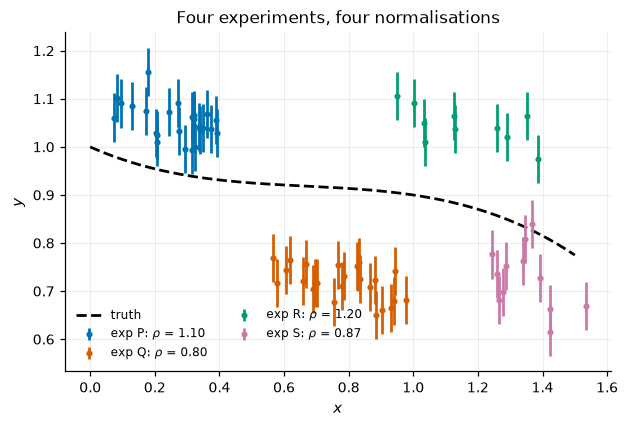

In [4]:
fig, ax = plt.subplots()
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
for (label, d), colour in zip(datasets.items(), plotstyle.COLOURS):
    ax.errorbar(
        d.x,
        d.y,
        d.y_err,
        fmt="o",
        ms=3,
        color=colour,
        label=rf"{label}: $\rho$ = {settings[label]['rho']:.2f}",
    )
ax.set(xlabel="$x$", ylabel="$y$", title="Four experiments, four normalisations")
ax.legend(fontsize=8, ncol=2)
plt.show()

## The model
The truth is a cubic, $y = a_0 + a_1 x + a_2 x^2 + a_3 x^3$. We will infer all four coefficients, as well as the normalization of each experiment

In [5]:
# a constant term is expected to be small, so a_0 gets a narrower prior than
# the shape coefficients; that also shrinks the volume the sampler must search
coeffs = [
    rx.Parameter(f"a{k}", prior=stats.norm(0.0, 0.5 if k == 0 else 1.5), latex=f"a_{k}")
    for k in (0, 1, 2, 3)
]
cubic = rx.Model(lambda x, *a: P.polyval(np.asarray(x, dtype=float), a), coeffs)
comps = {label: rx.Comparison(d, cubic) for label, d in datasets.items()}

## How we sample

We'll use [nested sampling](https://en.wikipedia.org/wiki/Nested_sampling_algorithm) through [dynesty](https://dynesty.readthedocs.io/) ([Speagle 2020](https://doi.org/10.1093/mnras/staa278)) for every fit in this notebook, rather than an ensemble sampler like emcee.

In [6]:
def fit(problem, seed, nlive=250):
    sampler = dynesty.NestedSampler(
        problem.log_likelihood,
        problem.prior_transform,
        problem.ndim,
        nlive=nlive,
        sample="rwalk",
        rstate=np.random.default_rng(seed),
    )
    sampler.run_nested(dlogz=0.5, print_progress=False)
    fit.logz[problem] = (sampler.results.logz[-1], sampler.results.logzerr[-1])
    return sampler.results.samples_equal(rstate=np.random.default_rng(seed))


fit.logz = {}


def curves(problem, samples, grid, n=200):
    # the bare cubic's curves on a grid: the physics, not the renormalised data
    rows = samples[np.random.default_rng(0).choice(len(samples), n, replace=False)]
    return rx.predictive.grid_draws(
        problem, cubic.bind(grid), grid, rows, model_only=True, return_draws=True
    )

### The three good approaches (1,2,3):

In [7]:
rhos = {
    label: rx.Parameter(
        f"log_rho_{i}",
        prior=stats.norm(0.0, np.log1p(settings[label]["sys"])),
        latex=rf"\log\rho_{i}",
    )
    for i, label in enumerate(comps)
}
etas = {
    label: rx.Parameter(
        f"log_eta_{i}",
        prior=stats.norm(np.log(settings[label]["sys"]), 0.7),
        latex=rf"\log\eta_{i}",
    )
    for i, label in enumerate(comps)
}
comps_scaled = [
    (
        rx.Comparison(d, cubic | tf.scale(rhos[label]))
        if label in comps
        else rx.Comparison(d, cubic)
    )
    for label, d in datasets.items()
]

In [8]:
correct = {
    "quoted systematics": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[t for label in comps for t in comps[label].reported_terms()],
            )
        ]
    ),
    "inferred systematics": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[
                    T.normalization(parameter=etas[label], on=comps[label])
                    for label in comps
                ],
            )
        ]
    ),
    "inferred normalisations": rx.Problem([rx.Constraint(comps_scaled)]),
}
for name, p in correct.items():
    print(f"{name:24s} {p.names}")

quoted systematics       ['a0', 'a1', 'a2', 'a3']
inferred systematics     ['a0', 'a1', 'a2', 'a3', 'log_eta_0', 'log_eta_1', 'log_eta_2', 'log_eta_3']
inferred normalisations  ['a0', 'a1', 'a2', 'a3', 'log_rho_0', 'log_rho_1', 'log_rho_2', 'log_rho_3']


## Three things not to do:

**4. Peelle's Pertinent Puzzle (recipe 27).**  Try to believe the experimentally reported uncertainties as in 2, but make the mistake of using the experimental data $y_i$ in systematic term in the covariance, rather than the model prediction $y_m(x_i;\alpha)$ 

**5. Ignore the systematics.**  Take the experimentally reported statistical errors only, as if every
normalisation were exact. 

**6. Infer statistical uncertainties instead.**  Notice that the datasets disagree, but blame the noise rather than systematic effects. Add a free diagonal noise term to the covariance to absorb it, and infer its scale. 

In [9]:
log_eps = rx.Parameter(
    "log_eps", prior=stats.norm(np.log(0.02), 1.0), latex=r"\log\epsilon"
)
wrong = {
    "PPP: mode from the data": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[
                    rx.Term(
                        settings[label]["sys"] * datasets[label].y,
                        kind="mode",
                        on=comps[label],
                    )
                    for label in comps
                ],
            )
        ]
    ),
    "systematics ignored": rx.Problem([rx.Constraint(list(comps.values()))]),
    "statistics inferred": rx.Problem(
        [
            rx.Constraint(
                list(comps.values()),
                terms=[T.proportional_error(log_eps)],
                statistical=False,
            )
        ]
    ),
}
for name, p in wrong.items():
    print(f"{name:24s} {p.names}")

PPP: mode from the data  ['a0', 'a1', 'a2', 'a3']
systematics ignored      ['a0', 'a1', 'a2', 'a3']
statistics inferred      ['a0', 'a1', 'a2', 'a3', 'log_eps']


In [10]:
%%time
problems = {**correct, **wrong}
samples = {name: fit(p, seed=i) for i, (name, p) in enumerate(problems.items())}

CPU times: user 22min 40s, sys: 191 ms, total: 22min 40s
Wall time: 10min 3s


In [11]:
style = dict(
    zip(
        problems,
        zip(
            [plotstyle.COLOURS[i] for i in (0, 2, 1, 4, 3, 6)],
            plotstyle.HATCHES + plotstyle.HATCHES,
        ),
    )
)

All six fits sit close to the truth on the scale of the data, so we show them twice.  First the three defensible treatments as 90 % bands over the data itself.  Then the three mistaken ones as *residuals*, the fitted curve minus the truth: a band that contains zero at some $x$ covers the truth there.  The grey region marks the high-$x$ range that `exp R` dominates — the dataset that quoted 5 % and is actually 20 % off — which is where a treatment that takes that quote at face value gets pulled away from the truth.

In [12]:
bands = {
    name: np.percentile(curves(problems[name], samples[name], x_fine), [5, 95], axis=0)
    for name in problems
}

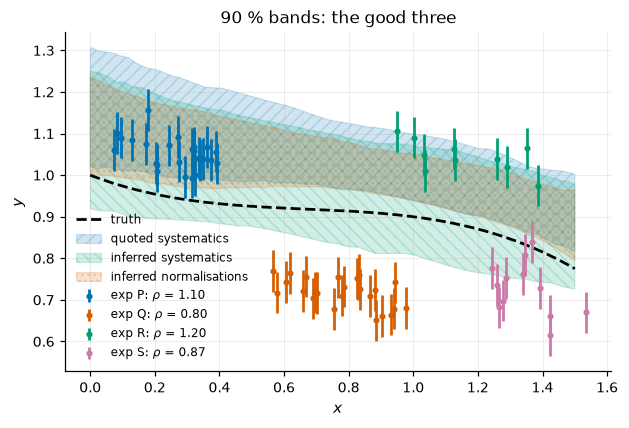

In [13]:
fig, ax = plt.subplots()
ax.plot(x_fine, truth(x_fine), "--", color="k", label="truth")
for (label, d), colour in zip(datasets.items(), plotstyle.COLOURS):
    ax.errorbar(
        d.x,
        d.y,
        d.y_err,
        fmt="o",
        ms=3,
        color=colour,
        label=rf"{label}: $\rho$ = {settings[label]['rho']:.2f}",
    )
for name in correct:
    colour, hatch = style[name]
    lo, hi = bands[name]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
ax.set(
    xlabel="$x$",
    ylabel=r"$y$",
    title="90 % bands: the good three",
)
ax.legend(fontsize=8)
plt.show()

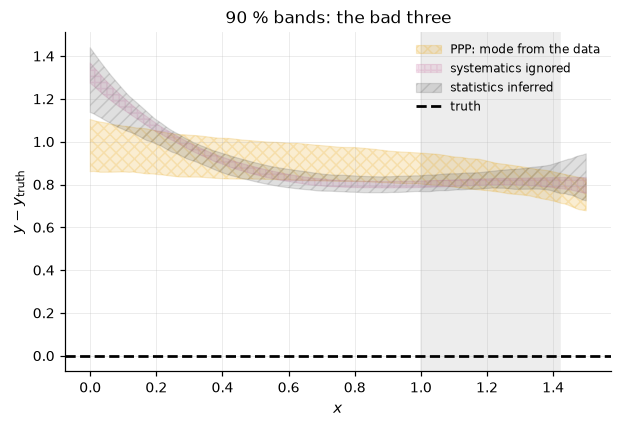

In [14]:
fig, ax = plt.subplots()
for name in wrong:
    colour, hatch = style[name]
    lo, hi = bands[name]
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
ax.axhline(0.0, ls="--", color="k", label="truth")
ax.axvspan(1.0, 1.42, color="0.93", zorder=0)
ax.set(
    xlabel="$x$",
    ylabel=r"$y - y_\mathrm{truth}$",
    title="90 % bands: the bad three",
)
ax.legend(fontsize=8)
plt.show()

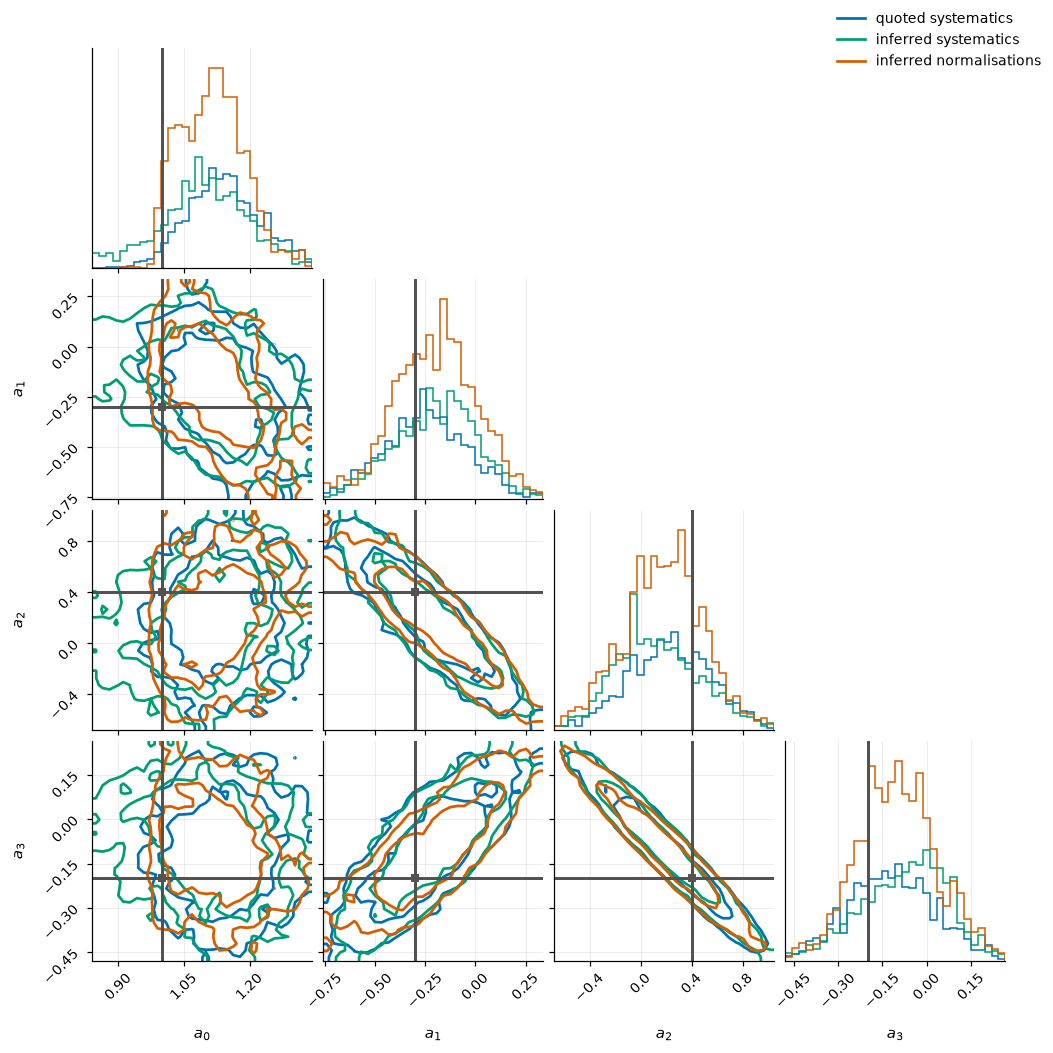

In [15]:
# zoom to the two cases that recover the curve: the quoted-systematics
# posterior is so wide that its range would flatten the others to points
tight = np.vstack(
    [
        samples[name][:, problems[name].columns(cubic.params)]
        for name in ("inferred normalisations", "inferred systematics")
    ]
)
span = list(zip(*np.percentile(tight, [0.5, 99.5], axis=0)))
fig = None
for name in correct:
    colour, _ = style[name]
    p = problems[name]
    fig = corner.corner(
        samples[name][:, p.columns(cubic.params)],
        fig=fig,
        labels=[f"${c.latex}$" for c in cubic.params],
        truths=a_true,
        range=span,
        **plotstyle.corner_kwargs(
            color=colour,
            fill_contours=False,
            plot_density=False,
            show_titles=False,
            levels=(0.68, 0.95),
        ),
    )
fig.legend(
    handles=[plt.Line2D([], [], color=style[n][0], label=n) for n in correct],
    loc="upper right",
    fontsize=9,
)
plt.show()

### What the normalisations came out as

Two of the defensible cases infer a number per dataset, and we can hold them up
against the renormalisations we planted.  Case 2 infers the scale $\rho_i$
directly.  Case 3 infers the *width* $\eta_i$ of the mode, so it does not say
which way a dataset moved, only how far it is prepared to let it move.

Watch `exp R`, which quoted 5 % and is off by 20 %, four times its own
quote, and `exp Q`, which quoted 25 % and is off by 20 % — comfortably
inside what it allowed.

In [16]:
p_rho, s_rho = correct["inferred normalisations"], samples["inferred normalisations"]
p_eta, s_eta = correct["inferred systematics"], samples["inferred systematics"]
header = f"{'dataset':8s} {'quoted':>7s} {'true rho':>9s} {'inferred rho':>16s} {'inferred eta':>16s}"
print(header)
for label in comps:
    rho_draws = np.exp(s_rho[:, p_rho.columns(rhos[label])])
    eta_draws = np.exp(s_eta[:, p_eta.columns(etas[label])])
    print(
        f"{label:8s} {settings[label]['sys']:7.0%} {settings[label]['rho']:9.2f} "
        f"{rho_draws.mean():10.2f} +/- {rho_draws.std():.2f} "
        f"{eta_draws.mean():10.0%} +/- {eta_draws.std():.0%}"
    )

dataset   quoted  true rho     inferred rho     inferred eta
exp P        12%      1.10       0.98 +/- 0.05        13% +/- 8%
exp Q        25%      0.80       0.71 +/- 0.03        32% +/- 21%
exp R         5%      1.20       1.08 +/- 0.04        11% +/- 8%
exp S        10%      0.87       0.80 +/- 0.04        17% +/- 10%


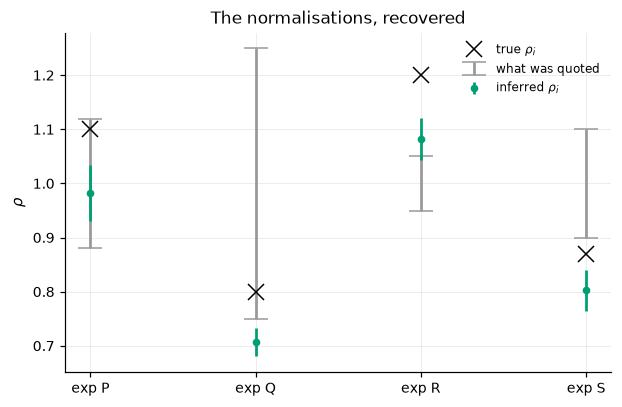

In [17]:
fig, ax = plt.subplots()
positions = np.arange(len(comps))
rho_mean = [np.exp(s_rho[:, p_rho.columns(rhos[label])]).mean() for label in comps]
rho_std = [np.exp(s_rho[:, p_rho.columns(rhos[label])]).std() for label in comps]
ax.errorbar(
    positions,
    np.ones(len(comps)),
    [settings[label]["sys"] for label in comps],
    fmt="none",
    ecolor="0.6",
    capsize=8,
    label="what was quoted",
)
ax.errorbar(
    positions,
    rho_mean,
    rho_std,
    fmt="o",
    color=plotstyle.COLOURS[2],
    label=r"inferred $\rho_i$",
)
ax.plot(
    positions,
    [settings[label]["rho"] for label in comps],
    "x",
    ms=11,
    color="k",
    label=r"true $\rho_i$",
)
ax.set(
    xticks=positions,
    xticklabels=list(comps),
    ylabel=r"$\rho$",
    title="The normalisations, recovered",
)
ax.legend(fontsize=8)
plt.show()

## A gallery of covariance structures

Every term writes a pattern into $\Sigma$, and `constraint.matrix(theta)` hands
us the assembled covariance at any parameter values, so we can simply look.

In [18]:
def correlation(S):
    d = np.sqrt(np.diag(S))
    return S / np.outer(d, d)


def show(ax, S, title, dividers=()):
    im = ax.imshow(correlation(S), cmap="RdBu_r", vmin=-1, vmax=1)
    for k in dividers:
        ax.axhline(k - 0.5, color="k", lw=0.5)
        ax.axvline(k - 0.5, color="k", lw=0.5)
    ax.set(title=title, xticks=[], yticks=[])
    ax.grid(False)
    return im


first = comps["exp P"]
theta_map = np.median(samples["quoted systematics"], axis=0)[: len(cubic.params)]

### 1. A systematic correlated across $x$: flat mode versus smooth kernel

A normalisation is a rank-one mode: every pair of points is correlated by the
same fraction, however far apart they are.  A Gaussian-process kernel instead
correlates neighbours in $x$ and forgets across the range.  Both are one term.

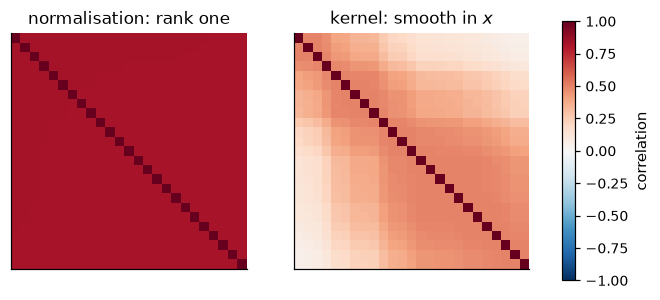

In [19]:
p_flat = rx.Problem([rx.Constraint([first], terms=[T.normalization(magnitude=0.1)])])
p_kernel = rx.Problem(
    [
        rx.Constraint(
            [first],
            terms=[T.kernel(ConstantKernel(0.05**2, "fixed") * RBF(0.15, "fixed"))],
        )
    ]
)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
show(axes[0], p_flat.constraints[0].matrix(theta_map), "normalisation: rank one")
im = show(axes[1], p_kernel.constraints[0].matrix(theta_map), "kernel: smooth in $x$")
fig.colorbar(im, ax=axes, shrink=0.85, label="correlation")
plt.show()

### 2. Correlated statistical errors: bring the matrix, do not diagonalise it

If an experiment reports a full statistical covariance, we pass it as a fixed
`Term`.  Treating correlated noise as independent over-counts the information,
and the naive posterior comes out tighter than the correct one — tighter and
wrong, which is the theme of this notebook.

In [20]:
xs = np.linspace(0.0, 4.0, 20)
C = 0.15**2 * np.exp(-np.abs(xs[:, None] - xs[None, :]) / 1.2)
a_line = np.array([1.0, 0.8])
y_corr = a_line[0] + a_line[1] * xs + rng.multivariate_normal(np.zeros(20), C)
d_corr = rx.Dataset(xs, y_corr, np.sqrt(np.diag(C)), label="correlated noise")
m_ = rx.Parameter("m", prior=stats.norm(0, 5), latex="m")
b_ = rx.Parameter("b", prior=stats.norm(0, 5), latex="b")
line = rx.Model(lambda x, m, b: b + m * x, [m_, b_])
c_full = rx.Constraint(
    [rx.Comparison(d_corr, line)], terms=[rx.Term(C, kind="matrix")], statistical=False
)
c_diag = rx.Constraint([rx.Comparison(d_corr, line)])
s_full = fit(rx.Problem([c_full]), seed=11)
s_diag = fit(rx.Problem([c_diag]), seed=12)
print(
    f"diagonal only: m = {s_diag[:, 0].mean():.3f} +/- {s_diag[:, 0].std():.3f}   "
    f"full matrix: m = {s_full[:, 0].mean():.3f} +/- {s_full[:, 0].std():.3f}"
)

diagonal only: m = 0.779 +/- 0.029   full matrix: m = 0.796 +/- 0.050


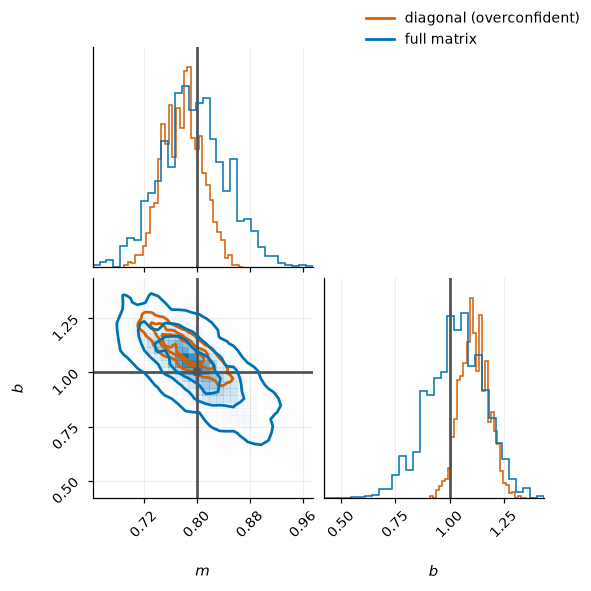

In [21]:
fig = corner.corner(
    s_diag,
    labels=["$m$", "$b$"],
    truths=[0.8, 1.0],
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[1], fill_contours=False, show_titles=False
    ),
)
corner.corner(
    s_full,
    fig=fig,
    **plotstyle.corner_kwargs(
        color=plotstyle.COLOURS[0], fill_contours=False, show_titles=False
    ),
)
fig.legend(
    handles=[
        plt.Line2D(
            [], [], color=plotstyle.COLOURS[1], label="diagonal (overconfident)"
        ),
        plt.Line2D([], [], color=plotstyle.COLOURS[0], label="full matrix"),
    ],
    loc="upper right",
)
plt.show()

### 3. Unknown or misreported magnitudes

A `proportional_error` term scales with the prediction, and its fraction sets how far
the total error exceeds what was reported.

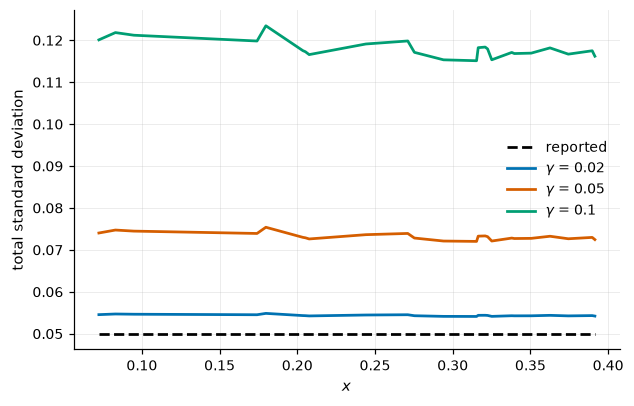

In [22]:
gamma = rx.Parameter(
    "log_gamma", prior=stats.norm(np.log(0.1), 0.5), latex=r"\log\gamma"
)
d0 = datasets["exp P"]
fig, ax = plt.subplots()
ax.plot(d0.x, d0.y_err, "--", color="k", label="reported")
for g, colour in zip((0.02, 0.05, 0.10), plotstyle.COLOURS):
    p = rx.Problem(
        [rx.Constraint([first], terms=[T.proportional_error(gamma, averaging=True)])]
    )
    total = np.sqrt(np.diag(p.constraints[0].matrix(np.append(theta_map, np.log(g)))))
    ax.plot(d0.x, total, color=colour, label=rf"$\gamma$ = {g}")
ax.set(xlabel="$x$", ylabel="total standard deviation")
ax.legend()
plt.show()

### 4. A systematic shared across datasets

The same normalisation term `on` two comparisons couples their blocks; one term
per comparison leaves the covariance block diagonal.  Which is right depends on
whether the two experiments really shared a calibration — the subject of
`sharing_error_models`.

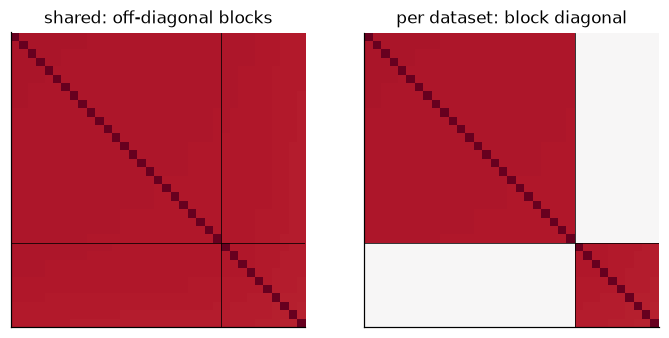

In [23]:
two = [comps["exp Q"], comps["exp R"]]
c_shared = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=two)])
c_each = rx.Constraint(two, terms=[T.normalization(magnitude=0.1, on=c) for c in two])
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.6))
for ax, c, title in zip(
    axes,
    (c_shared, c_each),
    ("shared: off-diagonal blocks", "per dataset: block diagonal"),
):
    show(
        ax,
        rx.Problem([c]).constraints[0].matrix(theta_map),
        title,
        dividers=(datasets["exp Q"].n,),
    )
plt.show()